# Analyse les résultats des métriques d'évaluation

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
gamma_vals = [0.1, 0.5, 1.0, 2.0, 5.0]
csv = "/tempory/21234701/blast_cluster_validation_scores"

/tmp/ipykernel_5331/2269406693.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_nodes_long, x="gamma", y="Nombre de nœuds", ax=axs[1, 1], palette="Set2")
/tmp/ipykernel_5331/2269406693.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_edges_long, x="gamma", y="Nombre d'arêtes", ax=axs[2, 0], palette="Set1")


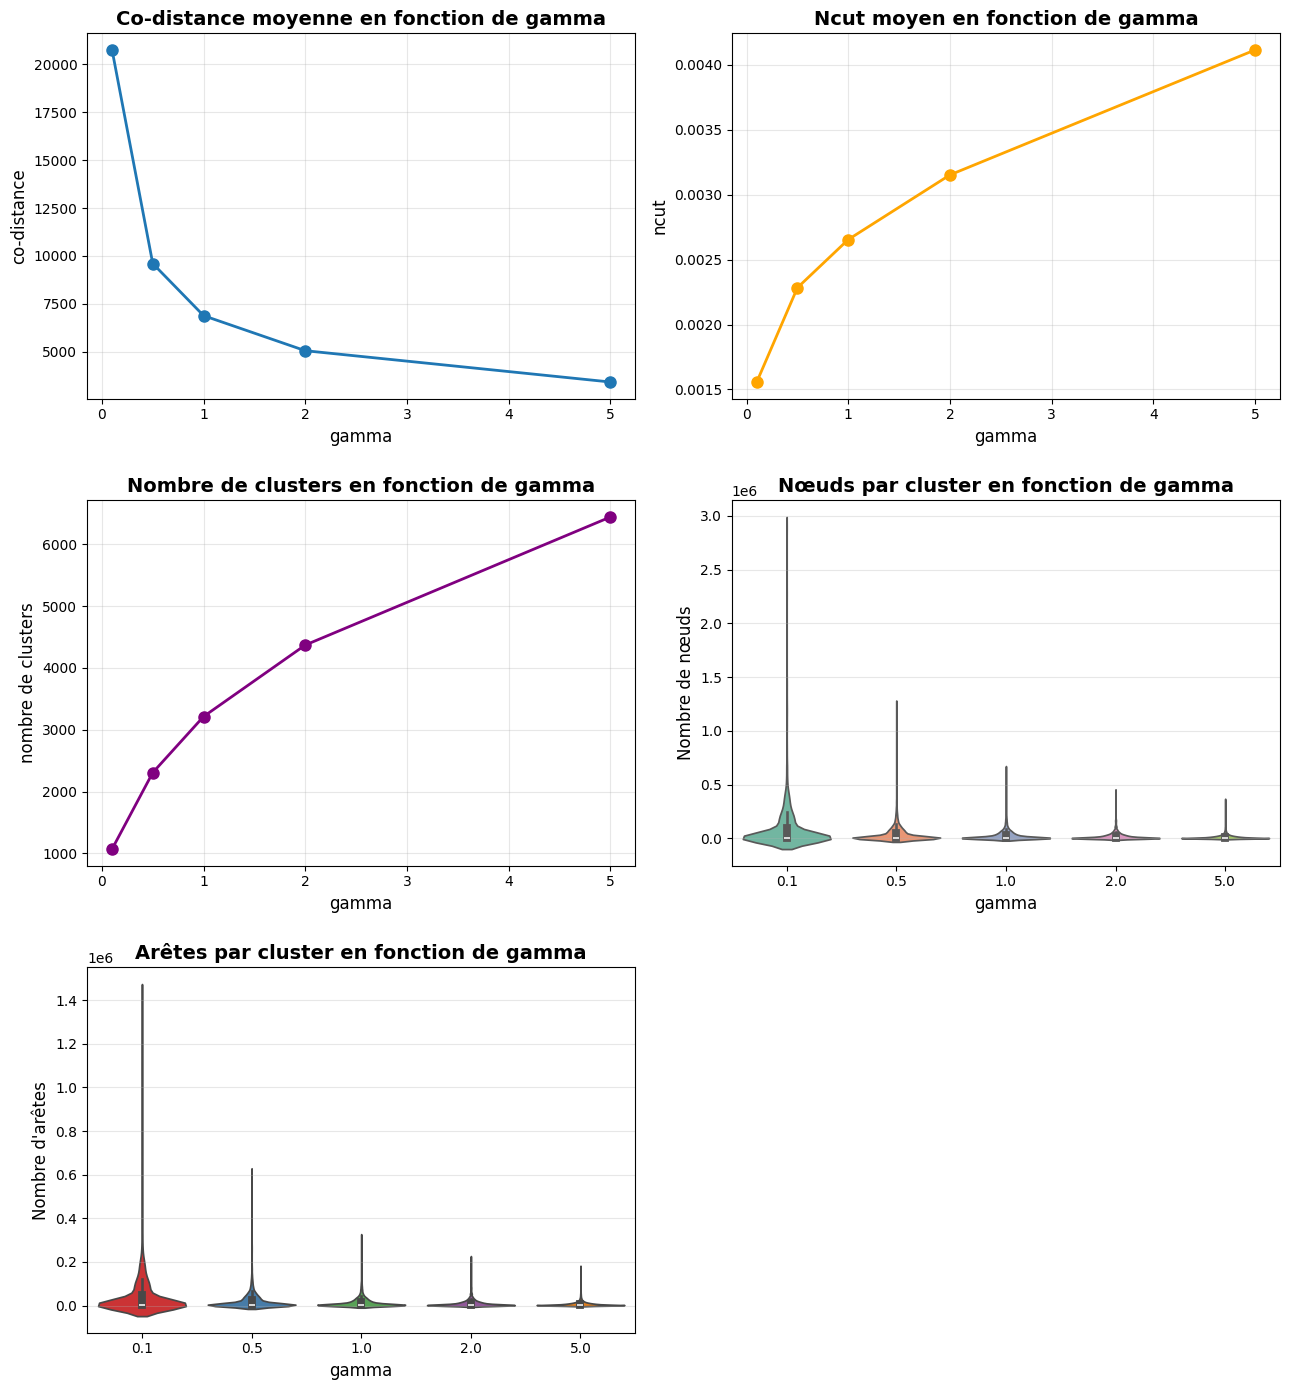

In [16]:
fig, axs = plt.subplots(3, 2, figsize=(13, 14))

co_dist_list = []
ncut_list = []
nb_clusters_list = []
df_nodes_list = []
df_edges_list = []

for gamma in gamma_vals:
    df = pd.read_csv(csv + f"_{gamma}.csv")

    nb_clusters_list.append(df["cluster_id"].nunique())
    co_dist_list.append(df["co_distance"].mean())
    ncut_list.append(df["ncut"].mean())
    df_nodes_list.append(df["nb_nodes"])
    df_edges_list.append(df["nb_edges"])

x = np.arange(len(gamma_vals))

# Courbe co-distance
axs[0, 0].plot(gamma_vals, co_dist_list, marker="o", linewidth=2, markersize=8)
axs[0, 0].set_xlabel("gamma", fontsize=12)
axs[0, 0].set_ylabel("co-distance", fontsize=12)
axs[0, 0].set_title("Co-distance moyenne en fonction de gamma", fontsize=14, fontweight="bold")
axs[0, 0].grid(True, alpha=0.3)

# Courbe ncut
axs[0, 1].plot(gamma_vals, ncut_list, marker="o", color="orange", linewidth=2, markersize=8)
axs[0, 1].set_xlabel("gamma", fontsize=12)
axs[0, 1].set_ylabel("ncut", fontsize=12)
axs[0, 1].set_title("Ncut moyen en fonction de gamma", fontsize=14, fontweight="bold")
axs[0, 1].grid(True, alpha=0.3)

# Courbe nombre de clusters
axs[1, 0].plot(gamma_vals, nb_clusters_list, marker="o", color="purple", linewidth=2, markersize=8)
axs[1, 0].set_xlabel("gamma", fontsize=12)
axs[1, 0].set_ylabel("nombre de clusters", fontsize=12)
axs[1, 0].set_title("Nombre de clusters en fonction de gamma", fontsize=14, fontweight="bold")
axs[1, 0].grid(True, alpha=0.3)

# Violin plot nb_nodes - prepare data in long format
nodes_data = []
for i, gamma in enumerate(gamma_vals):
    for value in df_nodes_list[i]:
        nodes_data.append({"gamma": str(gamma), "Nombre de nœuds": value})
df_nodes_long = pd.DataFrame(nodes_data)

sns.violinplot(data=df_nodes_long, x="gamma", y="Nombre de nœuds", ax=axs[1, 1], palette="Set2")
axs[1, 1].set_xlabel("gamma", fontsize=12)
axs[1, 1].set_ylabel("Nombre de nœuds", fontsize=12)
axs[1, 1].set_title("Nœuds par cluster en fonction de gamma", fontsize=14, fontweight="bold")
axs[1, 1].grid(True, alpha=0.3, axis="y")

# Violin plot nb_edges - prepare data in long format
edges_data = []
for i, gamma in enumerate(gamma_vals):
    for value in df_edges_list[i]:
        edges_data.append({"gamma": str(gamma), "Nombre d'arêtes": value})
df_edges_long = pd.DataFrame(edges_data)

sns.violinplot(data=df_edges_long, x="gamma", y="Nombre d'arêtes", ax=axs[2, 0], palette="Set1")
axs[2, 0].set_xlabel("gamma", fontsize=12)
axs[2, 0].set_ylabel("Nombre d'arêtes", fontsize=12)
axs[2, 0].set_title("Arêtes par cluster en fonction de gamma", fontsize=14, fontweight="bold")
axs[2, 0].grid(True, alpha=0.3, axis="y")

# On masque le dernier subplotplt.show()
axs[2, 1].axis("off")

plt.tight_layout()
plt.savefig("./Images/leiden_all_metrics_gamma.png", bbox_inches="tight")